# Carga de Datos y Librerías

In [1]:
pip install ipykernel pandas pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import sys
!{sys.executable} -m pip install seaborn matplotlib
!pip install seaborn matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

"c:\Users\FernandaCorrea\Documents\Documentos" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
a = pd.read_csv("../data/listings_plataforma_A.csv")
b = pd.read_csv("../data/listings_plataforma_B.csv")
c = pd.read_csv("../data/listings_plataforma_C.csv")

print("Los archivos se cargaron correctamente.")

Los archivos se cargaron correctamente.


# Exploración y Limpieza de Datos

## Base de datos A

In [99]:
a.head()

,id_aviso,titulo,zona_barrio,tipo,precio,expensas,superficie_total,superficie_cubierta,ambientes,dormitorios,...,longitud,fecha_publicacion,moneda,precio_limpio,fecha_dt,mes_anio,precio_usd,ambientes_num,superficie_promedio_ambiente,precio_m2_cubierto
0,A-700480,Departamento en alquiler en Belgrano - 4 ambie...,BELGRANO,Departamento,1.267.000,140298.0,75.0,75.0,4 amb.,3.0,...,-58.462834001141694,04/01/2025,ARS,1267000.0,2025-01-04,01-2025,1153.076083,4,18.75,15.374348
1,A-220016,Departamento en alquiler en Almagro - 2 ambientes,Almagro,Departamento,584.000,77822.0,39.0,39.0,2 amb.,1.0,...,-58.43909947532191,15/01/2024,ARS,584000.0,2024-01-15,01-2024,675.136704,2,19.50,17.311198
2,A-492142,Departamento en alquiler en Flores - 2 ambientes,Flores,Departamento,252.000,NaN,35.0,35.0,2,NaN,...,-58.45626733855754,07/03/2024,ARS,252000.0,2024-03-07,03-2024,279.580629,2,17.50,7.988018
3,A-675147,PH en alquiler en Belgrano - 2 ambientes,Belgrano,PH,546.000,NaN,38.0,38.0,2 amb.,1.0,...,-58.463757544997684,04/12/2024,ARS,546000.0,2024-12-04,12-2024,506.822612,2,19.00,13.337437
4,A-307536,Departamento en alquiler en Villa Urquiza - 1 ...,Villa Urquiza,Departamento,337.000,52942.0,33.0,33.0,1,NaN,...,-58.4866156408398,25/02/2024,ARS,337000.0,2024-02-25,02-2024,382.025529,1,33.00,11.576531


In [100]:
a.info()

<class 'pandas.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   id_aviso                      3662 non-null   str           
 1   titulo                        3662 non-null   str           
 2   zona_barrio                   3662 non-null   str           
 3   tipo                          3662 non-null   str           
 4   precio                        3662 non-null   str           
 5   expensas                      1990 non-null   float64       
 6   superficie_total              3662 non-null   float64       
 7   superficie_cubierta           3662 non-null   float64       
 8   ambientes                     3662 non-null   str           
 9   dormitorios                   3298 non-null   float64       
 10  banios                        3383 non-null   float64       
 11  antiguedad                    3342 non-nu

In [101]:
print("Tipos en A:", a['precio'].unique())

Tipos en A: <ArrowStringArray>
[    '1.267.000',       '584.000',       '252.000',       '546.000',
       '337.000',       '774.000',     '1.324.000',       'USD 741',
     '1.513.000',     '1.024.000',
 ...
   '$ 1.121.000',     '1.550.000', '$ 992.926.547',     '2.916.000',
     '$ 778.000',     '2.118.000',       '952.000',     '2.516.000',
     '3.102.000',     '$ 637.000']
Length: 1976, dtype: str


In [102]:
def extraer_moneda_y_limpiar(valor):
    if pd.isna(valor): return np.nan, np.nan
    valor_str = str(valor).upper()
    
    moneda = 'USD' if 'USD' in valor_str else 'ARS'
    
    solo_numeros = re.sub(r'[^\d]', '', valor_str)
    
    if solo_numeros == '': return moneda, np.nan
    return moneda, float(solo_numeros)

a[['moneda', 'precio_limpio']] = a['precio'].apply(lambda x: pd.Series(extraer_moneda_y_limpiar(x)))

print(a['moneda'].value_counts())

moneda
ARS    3313
USD     349
Name: count, dtype: int64


Se detectan valores en ARS (3313 registros) y USD (349 registros), por lo que se debe pasar todo a USD -moneda más estable- para unificar valores según el tipo de cambio utilizando el campo fecha_publicacion.

Se visualizan los nuevos campos creados a partir del campo precio, el precio_limpio (sin strings y pasado a numérico) y la moneda.

In [103]:
a.head()

,id_aviso,titulo,zona_barrio,tipo,precio,expensas,superficie_total,superficie_cubierta,ambientes,dormitorios,...,longitud,fecha_publicacion,moneda,precio_limpio,fecha_dt,mes_anio,precio_usd,ambientes_num,superficie_promedio_ambiente,precio_m2_cubierto
0,A-700480,Departamento en alquiler en Belgrano - 4 ambie...,BELGRANO,Departamento,1.267.000,140298.0,75.0,75.0,4 amb.,3.0,...,-58.462834001141694,04/01/2025,ARS,1267000.0,2025-01-04,01-2025,1153.076083,4,18.75,15.374348
1,A-220016,Departamento en alquiler en Almagro - 2 ambientes,Almagro,Departamento,584.000,77822.0,39.0,39.0,2 amb.,1.0,...,-58.43909947532191,15/01/2024,ARS,584000.0,2024-01-15,01-2024,675.136704,2,19.50,17.311198
2,A-492142,Departamento en alquiler en Flores - 2 ambientes,Flores,Departamento,252.000,NaN,35.0,35.0,2,NaN,...,-58.45626733855754,07/03/2024,ARS,252000.0,2024-03-07,03-2024,279.580629,2,17.50,7.988018
3,A-675147,PH en alquiler en Belgrano - 2 ambientes,Belgrano,PH,546.000,NaN,38.0,38.0,2 amb.,1.0,...,-58.463757544997684,04/12/2024,ARS,546000.0,2024-12-04,12-2024,506.822612,2,19.00,13.337437
4,A-307536,Departamento en alquiler en Villa Urquiza - 1 ...,Villa Urquiza,Departamento,337.000,52942.0,33.0,33.0,1,NaN,...,-58.4866156408398,25/02/2024,ARS,337000.0,2024-02-25,02-2024,382.025529,1,33.00,11.576531


A partir del campo fecha_publicación bucaremos el tipo de cambio vigente al momento de publicar el el precio del alquiler del inmueble en ARS. 

In [104]:
print("Tipos en A:", a['fecha_publicacion'].unique())

Tipos en A: <ArrowStringArray>
['04/01/2025', '15/01/2024', '07/03/2024', '04/12/2024', '25/02/2024',
 '23/11/2024', '29/06/2024', '13/06/2025', '26/06/2024', '28/04/2025',
 ...
 '04/02/2025', '19/04/2025', '22/02/2025', '07/04/2024', '08/05/2024',
 '07/09/2024', '06/11/2024', '31/07/2024', '28/04/2024', '24/07/2024']
Length: 599, dtype: str


In [105]:
a['fecha_dt'] = pd.to_datetime(a['fecha_publicacion'], dayfirst=True)

print(f"Desde: {a['fecha_dt'].min()} hasta {a['fecha_dt'].max()}")

Desde: 2024-01-01 00:00:00 hasta 2025-08-23 00:00:00


In [106]:

# Se crea columna de 'Mes-Año' para cruzar con cotización del dólar en la fecha correspondiente:
a['mes_anio'] = a['fecha_dt'].dt.strftime('%m-%Y')

print("Rango de fechas detectado:")
print(f"Desde: {a['fecha_dt'].min()}")
print(f"Hasta: {a['fecha_dt'].max()}")

print("\nConteo por mes-año:")
print(a['mes_anio'].value_counts().sort_index())

Rango de fechas detectado:
Desde: 2024-01-01 00:00:00
Hasta: 2025-08-23 00:00:00

Conteo por mes-año:
mes_anio
01-2024    175
01-2025    176
02-2024    187
02-2025    172
03-2024    198
03-2025    197
04-2024    170
04-2025    172
05-2024    193
05-2025    220
06-2024    197
06-2025    208
07-2024    186
07-2025    183
08-2024    183
08-2025    142
09-2024    155
10-2024    199
11-2024    178
12-2024    171
Name: count, dtype: int64


In [107]:
a.head()

,id_aviso,titulo,zona_barrio,tipo,precio,expensas,superficie_total,superficie_cubierta,ambientes,dormitorios,...,longitud,fecha_publicacion,moneda,precio_limpio,fecha_dt,mes_anio,precio_usd,ambientes_num,superficie_promedio_ambiente,precio_m2_cubierto
0,A-700480,Departamento en alquiler en Belgrano - 4 ambie...,BELGRANO,Departamento,1.267.000,140298.0,75.0,75.0,4 amb.,3.0,...,-58.462834001141694,04/01/2025,ARS,1267000.0,2025-01-04,01-2025,1153.076083,4,18.75,15.374348
1,A-220016,Departamento en alquiler en Almagro - 2 ambientes,Almagro,Departamento,584.000,77822.0,39.0,39.0,2 amb.,1.0,...,-58.43909947532191,15/01/2024,ARS,584000.0,2024-01-15,01-2024,675.136704,2,19.50,17.311198
2,A-492142,Departamento en alquiler en Flores - 2 ambientes,Flores,Departamento,252.000,NaN,35.0,35.0,2,NaN,...,-58.45626733855754,07/03/2024,ARS,252000.0,2024-03-07,03-2024,279.580629,2,17.50,7.988018
3,A-675147,PH en alquiler en Belgrano - 2 ambientes,Belgrano,PH,546.000,NaN,38.0,38.0,2 amb.,1.0,...,-58.463757544997684,04/12/2024,ARS,546000.0,2024-12-04,12-2024,506.822612,2,19.00,13.337437
4,A-307536,Departamento en alquiler en Villa Urquiza - 1 ...,Villa Urquiza,Departamento,337.000,52942.0,33.0,33.0,1,NaN,...,-58.4866156408398,25/02/2024,ARS,337000.0,2024-02-25,02-2024,382.025529,1,33.00,11.576531


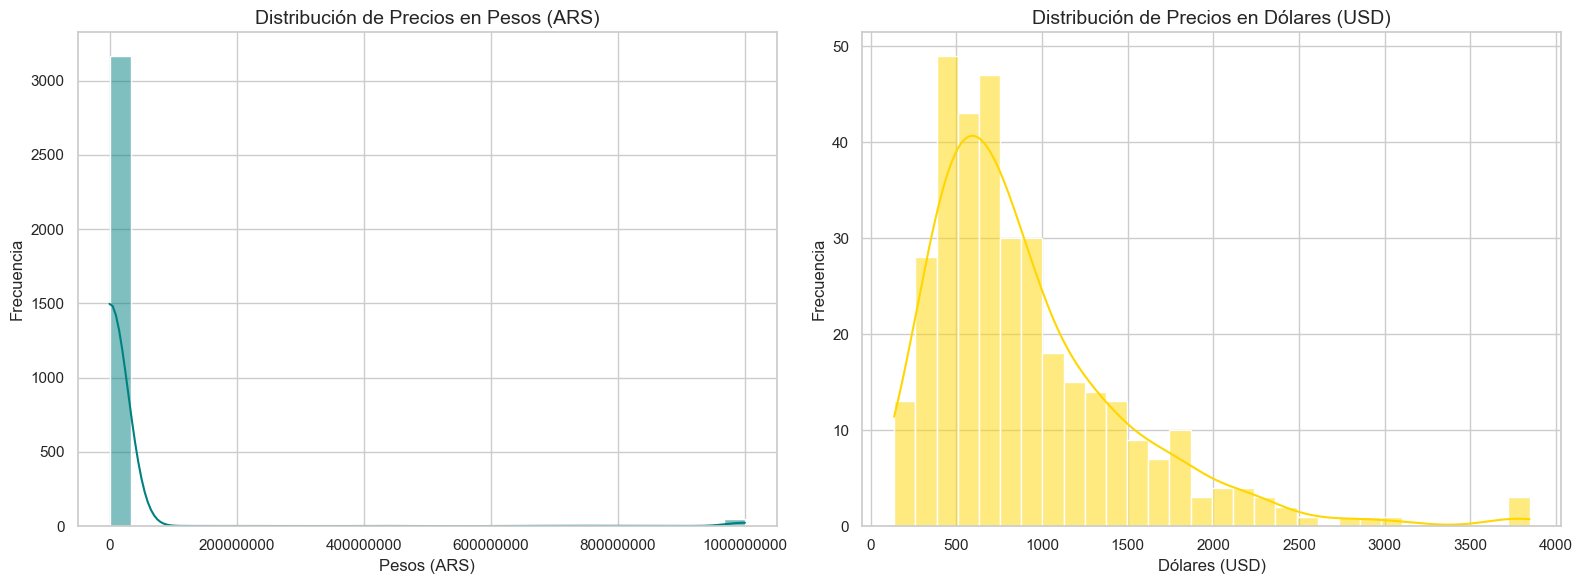

In [108]:
##Se visualiza la distribución de precios en USD y en ARS:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


data_ars = a[(a['moneda'] == 'ARS')]['precio_limpio']


sns.histplot(data_ars, kde=True, color="teal", bins=30, ax=axes[0])
axes[0].set_title('Distribución de Precios en Pesos (ARS)', fontsize=14)
axes[0].set_xlabel('Pesos (ARS)')
axes[0].set_ylabel('Frecuencia')
# Formato para que no aparezca 1e7
axes[0].ticklabel_format(style='plain', axis='x') 

data_usd = a[a['moneda'] == 'USD']['precio_limpio']

sns.histplot(data_usd, kde=True, color="gold", bins=30, ax=axes[1])
axes[1].set_title('Distribución de Precios en Dólares (USD)', fontsize=14)
axes[1].set_xlabel('Dólares (USD)')
axes[1].set_ylabel('Frecuencia')


plt.tight_layout()
plt.show()

Como se puede observar, la distribición en precios presenta un claro outlier (el valor de 1000000000) que se debe filtrar.
Asimismo, con la cotización promedio de cada mes-año, del tipo de cambio minorista Comunicación B 9791 - Promedio vendedor del BCRA, se pasarán los valores en pesos a su valor correspondiente en USD, para llevarlo a una moneda más estable.

In [109]:
# Promedio mensual del tipo de cambio minorista de la Comunicación B 9791 - Promedio vendedor
cotizaciones_bcra = {
    '01-2024': 865.01, '02-2024': 882.14, '03-2024': 901.35, '04-2024': 921.22,
    '05-2024': 940.80, '06-2024': 958.45, '07-2024': 977.10, '08-2024': 995.30,
    '09-2024': 1015.20, '10-2024': 1035.50, '11-2024': 1056.20, '12-2024': 1077.30,
    '01-2025': 1098.80, '02-2025': 1120.70, '03-2025': 1143.10, '04-2025': 1165.90,
    '05-2025': 1189.20, '06-2025': 1213.00, '07-2025': 1237.20, '08-2025': 1261.90
}
#Filtramos aquellos precios mayores a $5.000.000 por ser outliers (posibles precios de venta de inmueble y no de alquiler)
def precio_USD(row):
    if pd.isna(row['precio_limpio']) or row['precio_limpio'] > 5000000:
        return np.nan
    
    if row['moneda'] == 'USD':
        return row['precio_limpio']
    
    # Se busca el promedio exacto del mes
    tasa = cotizaciones_bcra.get(row['mes_anio'])
    return row['precio_limpio'] / tasa if tasa else np.nan

# Se crea la columna definitiva a utilizar en el modelo
a['precio_usd'] = a.apply(precio_USD, axis=1)

print("Conversión completada con promedios exactos del BCRA.")
print(a[['mes_anio', 'moneda', 'precio_limpio', 'precio_usd']].head())

Conversión completada con promedios exactos del BCRA.
  mes_anio moneda  precio_limpio   precio_usd
0  01-2025    ARS      1267000.0  1153.076083
1  01-2024    ARS       584000.0   675.136704
2  03-2024    ARS       252000.0   279.580629
3  12-2024    ARS       546000.0   506.822612
4  02-2024    ARS       337000.0   382.025529


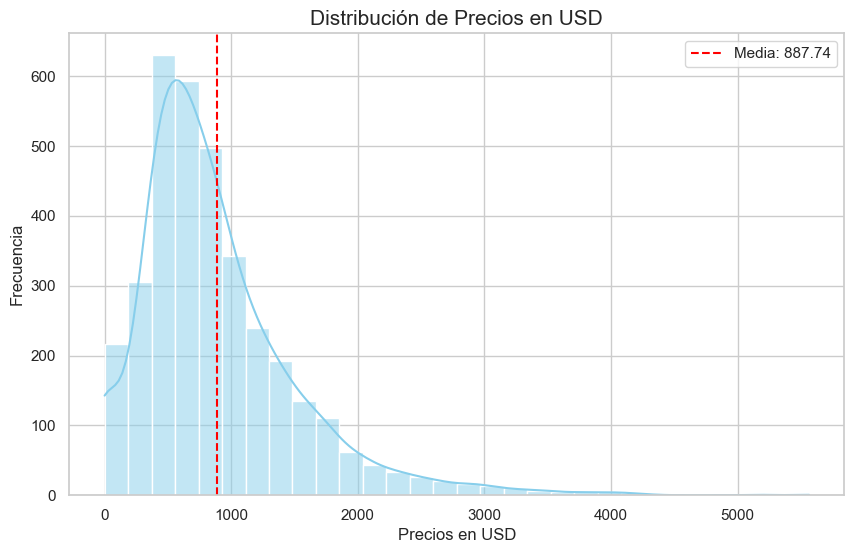

In [110]:
##Se visualiza la distribución del nuevo campo precio_usd:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Histograma
sns.histplot(a['precio_usd'], kde=True, color="skyblue", bins=30)

plt.axvline(a['precio_usd'].mean(), color='red', linestyle='--', label=f"Media: {a['precio_usd'].mean():.2f}")

plt.title('Distribución de Precios en USD', fontsize=15)
plt.xlabel('Precios en USD', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()

plt.show()

La variable precio_usd presenta una distribución log-normal, con una fuerte concentración en el segmento medio (USD 400-800) y una cola larga representativa del segmento más alto.

In [111]:
print("Tipos en A:", a['antiguedad'].unique())

Tipos en A: [ 4.  6. 23.  0.  2. 24. 16.  5. 13. 37. 19. 20. 26. 12. nan 36. 45. 52.
 29.  3.  7. 17.  9. 31.  8. 18. 11. 51. 40. 41. 15. 25. 54.  1. 14. 32.
 68. 27. 38. 42. 34. 21. 33. 22. 10. 44. 53. 30. 50. 70. 35. 43. 47. 56.
 67. 57. 46. 39. 49. 28. 73. 76. 59. 62. 64. 61. 48. 63. 60. 69. 71. 55.
 58. 66. 72.]


In [112]:
a['antiguedad'] = a['antiguedad'].str.lower().str.strip()

# Se reemplaza "a estrenar" por "0"
a['antiguedad'] = a['antiguedad'].replace('a estrenar', '0')

# Se quitan los strings "años"
a['antiguedad'] = a['antiguedad'].str.replace(r'[^\d]', '', regex=True)

# Se convierte a numérico (los que queden vacíos se vuelven NaN)
a['antiguedad'] = pd.to_numeric(a['antiguedad'], errors='coerce')

print("✅ Antigüedad normalizada. Valores únicos:")
print(a['antiguedad'].unique())

AttributeError: Can only use .str accessor with string values, not floating

In [ ]:
print("Tipos en A:", a['superficie_total'].unique())

Tipos en A: <ArrowStringArray>
[    '75',     '39',  '35 m²',  '38 m²',  '33 m²',     '76',  '66 m²',
  '37 m²',     '60', '102 m²',
 ...
 '143 m²', '152 m²', '156 m²',    '203', '178 m²',    '150', '188 m²',
    '162',    '117',    '149']
Length: 284, dtype: str


In [ ]:
a['superficie_total'] = (
    a['superficie_total']
    .str.replace(r'[^\d.]', '', regex=True)
    .replace('', np.nan)                    
    .astype(float)                          
)

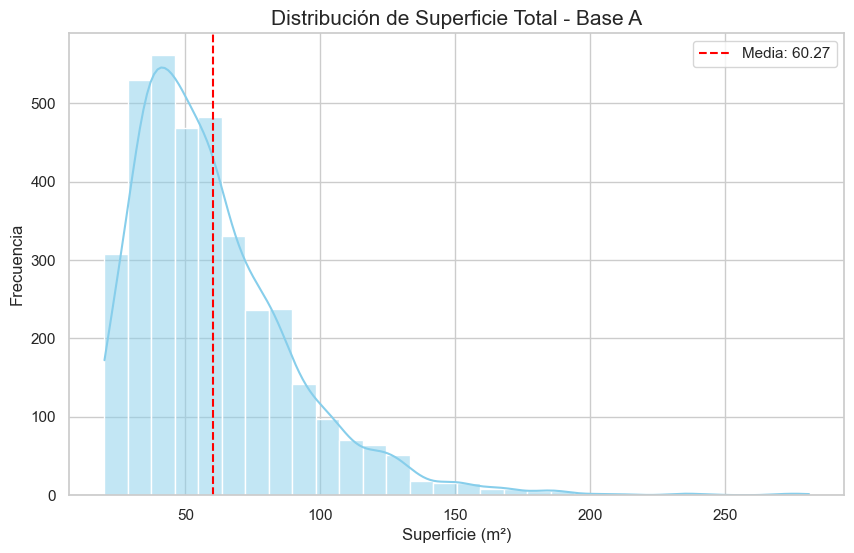

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Histograma
sns.histplot(a['superficie_total'], kde=True, color="skyblue", bins=30)

plt.axvline(a['superficie_total'].mean(), color='red', linestyle='--', label=f"Media: {a['superficie_total'].mean():.2f}")

plt.title('Distribución de Superficie Total - Base A', fontsize=15)
plt.xlabel('Superficie (m²)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()

plt.show()

In [ ]:

a['superficie_total'] = pd.to_numeric(a['superficie_total'], errors='coerce')
a['superficie_cubierta'] = pd.to_numeric(a['superficie_cubierta'], errors='coerce')

a['superficie_cubierta'] = a['superficie_cubierta'].fillna(a['superficie_total'])
a['superficie_cubierta'] = np.where(a['superficie_cubierta'] == 0, a['superficie_total'], a['superficie_cubierta'])

In [ ]:
print("Tipos en A:", a['ambientes'].unique())

Tipos en A: <ArrowStringArray>
['4 amb.', '2 amb.',      '2',      '1',      '3', '3 amb.', '6 amb.',
 '1 amb.',      '4',      '5',      '6', '5 amb.',      '7', '7 amb.',
      '8', '8 amb.']
Length: 16, dtype: str


In [ ]:
def limpiar_ambientes(valor):
    if pd.isna(valor):
        return np.nan
    
 #Se sacan los strings "amb."
    solo_numeros = re.sub(r'[^\d]', '', str(valor))
    
    if solo_numeros == '':
        return np.nan
    
    return int(solo_numeros)


a['ambientes_num'] = a['ambientes'].apply(limpiar_ambientes)

# Verificación los resultados únicos
print("Nuevos valores en ambientes_num:", sorted(a['ambientes_num'].dropna().unique()))

Nuevos valores en ambientes_num: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


Imputación: Ante muchos registros sin el dato de superficie_cubierta, usamos la superficie_total como proxy

In [ ]:
a['superficie_cubierta'] = a['superficie_cubierta'].fillna(a['superficie_total'])
a['superficie_cubierta'] = np.where(a['superficie_cubierta'] <= 0, a['superficie_total'], a['superficie_cubierta'])

In [ ]:
a.info()

<class 'pandas.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id_aviso             3662 non-null   str           
 1   titulo               3662 non-null   str           
 2   zona_barrio          3662 non-null   str           
 3   tipo                 3662 non-null   str           
 4   precio               3662 non-null   str           
 5   expensas             1990 non-null   float64       
 6   superficie_total     3662 non-null   float64       
 7   superficie_cubierta  3662 non-null   float64       
 8   ambientes            3662 non-null   str           
 9   dormitorios          3298 non-null   float64       
 10  banios               3383 non-null   float64       
 11  antiguedad           3342 non-null   float64       
 12  cochera              3662 non-null   str           
 13  balcon               3662 non-null   str    

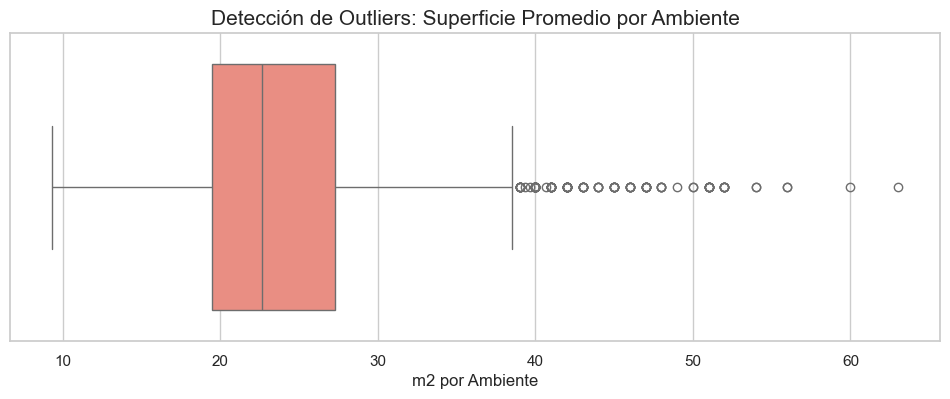

In [ ]:
# Se crea la variable superficio promedio por ambiente para ver si hay datos irracionales en cuanto a la relación cantidad de ambientes, superficie cubierta
a['superficie_promedio_ambiente'] = a['superficie_cubierta'] / a['ambientes_num']

plt.figure(figsize=(12, 4))

#Se analizan posibles outliers
sns.boxplot(x=a['superficie_promedio_ambiente'], color="salmon")

plt.title('Detección de Outliers: Superficie Promedio por Ambiente', fontsize=15)
plt.xlabel('m2 por Ambiente')
plt.show()

In [ ]:
# Se calcula el límite superior estadístico (Boxplot)
Q1 = a['superficie_promedio_ambiente'].quantile(0.25)
Q3 = a['superficie_promedio_ambiente'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR


# Outliers de superficie
outliers_altos = a[a['superficie_promedio_ambiente'] > limite_superior].copy()
precio_promedio_outliers = outliers_altos['precio_usd'].mean()

# Se filtran datos incongruentes :Precio bajo y Superficie alta
a_para_borrar = outliers_altos[outliers_altos['precio_usd'] < precio_promedio_outliers].copy()

# Se calcula el precio por m2 para detectar errores de carga
a_para_borrar['precio_m2_cubierto'] = a_para_borrar['precio_usd'] / a_para_borrar['superficie_cubierta']

# 4. Se seleccionan solo los que tienen precio por m2 menor o igual a 7 USD
lista_negra = a_para_borrar[a_para_borrar['precio_m2_cubierto'] <= 7].copy()

# 5. Columnas para mostrar (ajustado a 'zona_barrio')
columnas_inspeccion = [
    'zona_barrio', 
    'ambientes_num', 
    'superficie_cubierta', 
    'superficie_promedio_ambiente', 
    'precio_usd',
    'precio_m2_cubierto'
]

print(f"Límite superior estadístico: {limite_superior:.2f} m2/amb")
print(f"Se encontraron {len(lista_negra)} registros con precio por m2 <= 7 USD.")
display(lista_negra[columnas_inspeccion].sort_values(by='precio_m2_cubierto'))

Límite superior estadístico: 38.88 m2/amb
Se encontraron 10 registros con precio por m2 <= 7 USD.


,zona_barrio,ambientes_num,superficie_cubierta,superficie_promedio_ambiente,precio_usd,precio_m2_cubierto
1643,FLORES,2,80.0,40.0,0.000875,0.000011
1206,Villa Crespo,1,45.0,45.0,0.001063,0.000024
1102,Villa Crespo,1,39.0,39.0,0.001043,0.000027
742,boedo,1,48.0,48.0,0.115606,0.002408
3263,San Telmo,1,40.0,40.0,0.098503,0.002463
321,Caballito,1,40.0,40.0,0.113361,0.002834
1432,Palermo,1,48.0,48.0,0.946790,0.019725
2792,Villa Crespo,1,46.0,46.0,0.910084,0.019784
3570,Almagro,1,51.0,51.0,1.023437,0.020067
985,Villa Urquiza,1,46.0,46.0,1.023437,0.022249


Limpieza de base de datos A

In [ ]:
# Métrica precio_m2_cubierto:
a['precio_m2_cubierto'] = a['precio_usd'] / a['superficie_cubierta']

# Se filtran datos incongruentes
a_final = a[
    (a['superficie_promedio_ambiente'] >= 9) &           #se filtran superficies de hacinamiento
    (a['precio_m2_cubierto'] > 7) &                      #se filtran precios demasiado bajos
    ((a['superficie_promedio_ambiente'] <= limite_superior) | 
     (a['precio_usd'] >= precio_promedio_outliers))      # se filtran outliers de superficie sin justificación de precio
].copy()

print(f" Limpieza terminada.")
print(f"Registros originales: {len(a)}")
print(f"Registros finales: {len(a_final)}")

 Limpieza terminada.
Registros originales: 3662
Registros finales: 3216


In [ ]:
a_final.head()

,id_aviso,titulo,zona_barrio,tipo,precio,expensas,superficie_total,superficie_cubierta,ambientes,dormitorios,...,longitud,fecha_publicacion,moneda,precio_limpio,fecha_dt,mes_anio,precio_usd,ambientes_num,superficie_promedio_ambiente,precio_m2_cubierto
0,A-700480,Departamento en alquiler en Belgrano - 4 ambie...,BELGRANO,Departamento,1.267.000,140298.0,75.0,75.0,4 amb.,3.0,...,-58.462834001141694,04/01/2025,ARS,1267000.0,2025-01-04,01-2025,1153.076083,4,18.75,15.374348
1,A-220016,Departamento en alquiler en Almagro - 2 ambientes,Almagro,Departamento,584.000,77822.0,39.0,39.0,2 amb.,1.0,...,-58.43909947532191,15/01/2024,ARS,584000.0,2024-01-15,01-2024,675.136704,2,19.50,17.311198
2,A-492142,Departamento en alquiler en Flores - 2 ambientes,Flores,Departamento,252.000,NaN,35.0,35.0,2,NaN,...,-58.45626733855754,07/03/2024,ARS,252000.0,2024-03-07,03-2024,279.580629,2,17.50,7.988018
3,A-675147,PH en alquiler en Belgrano - 2 ambientes,Belgrano,PH,546.000,NaN,38.0,38.0,2 amb.,1.0,...,-58.463757544997684,04/12/2024,ARS,546000.0,2024-12-04,12-2024,506.822612,2,19.00,13.337437
4,A-307536,Departamento en alquiler en Villa Urquiza - 1 ...,Villa Urquiza,Departamento,337.000,52942.0,33.0,33.0,1,NaN,...,-58.4866156408398,25/02/2024,ARS,337000.0,2024-02-25,02-2024,382.025529,1,33.00,11.576531


In [ ]:
a_final.info()

<class 'pandas.DataFrame'>
Index: 3216 entries, 0 to 3660
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   id_aviso                      3216 non-null   str           
 1   titulo                        3216 non-null   str           
 2   zona_barrio                   3216 non-null   str           
 3   tipo                          3216 non-null   str           
 4   precio                        3216 non-null   str           
 5   expensas                      1736 non-null   float64       
 6   superficie_total              3216 non-null   float64       
 7   superficie_cubierta           3216 non-null   float64       
 8   ambientes                     3216 non-null   str           
 9   dormitorios                   2900 non-null   float64       
 10  banios                        2969 non-null   float64       
 11  antiguedad                    2941 non-null   

In [ ]:
print(a_final.columns.tolist())

['id_aviso', 'titulo', 'zona_barrio', 'tipo', 'precio', 'expensas', 'superficie_total', 'superficie_cubierta', 'ambientes', 'dormitorios', 'banios', 'antiguedad', 'cochera', 'balcon', 'amenities', 'latitud', 'longitud', 'fecha_publicacion', 'fecha_dt', 'moneda', 'precio_limpio', 'mes_anio', 'precio_usd', 'ambientes_num', 'superficie_promedio_ambiente', 'precio_m2_cubierto']


In [ ]:
print("Tipos en A:", a_final['tipo'].unique())

Tipos en A: <ArrowStringArray>
['Departamento', 'PH', 'Casa']
Length: 3, dtype: str


In [ ]:
print("Tipos en A:", a_final['amenities'].unique())

Tipos en A: <ArrowStringArray>
[nan, 'Pileta']
Length: 2, dtype: str


In [ ]:
# Transformamos el campo categorico "ameneties" en una dummy :
a_final = a_final.rename(columns={'amenities': 'pileta'})

a_final['pileta'] = a_final['pileta'].fillna('').apply(lambda x: 1 if 'pileta' in str(x).lower() else 0)

print("Conteo de valores en la nueva columna 'pileta':")
print(a_final['pileta'].value_counts())

display(a_final[['id_aviso', 'pileta']].head())

Conteo de valores en la nueva columna 'pileta':
pileta
0    2919
1     297
Name: count, dtype: int64


,id_aviso,pileta
0,A-700480,0
1,A-220016,0
2,A-492142,0
3,A-675147,1
4,A-307536,0


In [ ]:
print("Tipos en A:", a_final['cochera'].unique())

Tipos en A: <ArrowStringArray>
['Sí', 'No']
Length: 2, dtype: str


In [ ]:
# Transformamos el campo categorico "cochera" en una dummy :
a_final['cochera'] = a_final['cochera'].fillna('').apply(
    lambda x: 1 if 'sí' in str(x).lower() or 'si' in str(x).lower() or 'cochera' in str(x).lower() else 0
)

print("Conteo de valores en la nueva columna 'cochera':")
print(a_final['cochera'].value_counts())

display(a_final[['id_aviso', 'cochera']].head())

Conteo de valores en la nueva columna 'cochera':
cochera
0    1997
1    1219
Name: count, dtype: int64


,id_aviso,cochera
0,A-700480,1
1,A-220016,0
2,A-492142,1
3,A-675147,0
4,A-307536,0


In [ ]:
print("Tipos en A:", a_final['balcon'].unique())

Tipos en A: <ArrowStringArray>
['Sí', 'No']
Length: 2, dtype: str


In [ ]:
# Transformamos el campo categorico "balcon" en una dummy :
a_final['balcon'] = a_final['balcon'].fillna('').apply(
    lambda x: 1 if 'sí' in str(x).lower() or 'si' in str(x).lower() or 'balcon' in str(x).lower() else 0
)

print("Conteo de valores en la nueva columna 'balcon':")
print(a_final['balcon'].value_counts())

display(a_final[['id_aviso', 'balcon']].head())

Conteo de valores en la nueva columna 'balcon':
balcon
0    3216
Name: count, dtype: int64


,id_aviso,balcon
0,A-700480,0
1,A-220016,0
2,A-492142,0
3,A-675147,0
4,A-307536,0


Finalmente creamos una PK para poder unificar las tres bases y evitar registros duplicados entre las tres bases. Para eso construiremos una PK con las variables latitud, longitud, superficie y cantidad de ambientes, que llamaremos "PK".

In [ ]:
def crear_pk_cruce_texto(df, col_superficie):

    lat = df['latitud'].astype(str).str.strip().str.replace(' ', '')
    lon = df['longitud'].astype(str).str.strip().str.replace(' ', '')
    sup = df[col_superficie].astype(str).str.strip().str.replace(' ', '')
    
    # Se crea la PK
    return lat + "|" + lon + "|" + sup

# Aplicamos esta versión
a_final['PK'] = crear_pk_cruce_texto(a_final, 'superficie_cubierta')

print(f"Total de registros: {len(a_final)}")
print(f"Registros con PK generada: {a_final['PK'].notna().sum()}")

Total de registros: 3216
Registros con PK generada: 3216


In [ ]:
# Cuenta cuántos valores distintos hay en la columna PK
unicos = a_final['id_aviso'].nunique()
total = len(a_final)

print(f"Valores únicos: {unicos}")
print(f"Valores repetidos: {total - unicos}")

Valores únicos: 3213
Valores repetidos: 3


In [ ]:
# Cuenta cuántos valores distintos hay en la columna PK
unicos = a_final['PK'].nunique()
total = len(a_final)

print(f"Valores únicos: {unicos}")
print(f"Valores repetidos: {total - unicos}")

Valores únicos: 2777
Valores repetidos: 439


## Base de datos B

In [ ]:
b.head()

,listing_id,category_l1,category_l2,tipo,zona_barrio,price_ars,superficie_cubierta,superficie_total,ambientes_num,dormitorios,...,cochera,balcon,pileta,latitud,longitud,fecha_publicacion,fecha_dt,mes_anio,mes_anio_str,precio_usd
0,MLA757902287,Inmuebles,Alquiler,DEPARTAMENTO,Palermo,713000.0,50.0,50.0,NaN,2.0,...,0,1,0,-34.549232,-58.425510,2025-01-18 00:00:00,2025-01-18,2025-01,01-2025,648.889698
1,MLA371511639,Inmuebles,Alquiler,DEPARTAMENTO,Almagro,724000.0,50.0,50.0,2.0,1.0,...,0,0,0,-34.586467,-58.439921,2024-08-08 00:00:00,2024-08-08,2024-08,08-2024,727.418869
2,MLA154908801,Inmuebles,Alquiler,DEPARTAMENTO,Almagro,348000.0,42.0,NaN,2.0,NaN,...,1,0,0,-34.607493,-58.417589,2024-08-18 00:00:00,2024-08-18,2024-08,08-2024,349.643324
3,MLA403100436,Inmuebles,Alquiler,DEPARTAMENTO,Villa Urquiza,1217000.0,66.0,66.0,2.0,1.0,...,1,1,0,-34.567514,-58.487023,2024-11-03 00:00:00,2024-11-03,2024-11,11-2024,1152.243893
4,MLA346000441,Inmuebles,Alquiler,CASA,Palermo,1121000.0,86.0,164.0,3.0,2.0,...,1,0,1,-34.589963,-58.444575,2025-03-22 00:00:00,2025-03-22,2025-03,03-2025,980.666608


In [ ]:
b.info()

<class 'pandas.DataFrame'>
RangeIndex: 3639 entries, 0 to 3638
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   listing_id           3639 non-null   str           
 1   category_l1          3639 non-null   str           
 2   category_l2          3639 non-null   str           
 3   tipo                 3639 non-null   str           
 4   zona_barrio          3639 non-null   str           
 5   price_ars            3426 non-null   float64       
 6   superficie_cubierta  3452 non-null   float64       
 7   superficie_total     2939 non-null   float64       
 8   ambientes_num        3501 non-null   float64       
 9   dormitorios          3523 non-null   float64       
 10  banios               3497 non-null   float64       
 11  antiguedad           2568 non-null   float64       
 12  cochera              3639 non-null   int64         
 13  balcon               3639 non-null   int64  

In [ ]:
print(b.columns.tolist())

['listing_id', 'category_l1', 'category_l2', 'property_type', 'neighborhood', 'price_ars', 'covered_area_m2', 'total_area_m2', 'rooms', 'bedrooms', 'bathrooms', 'age_years', 'has_garage', 'has_balcony', 'has_pool', 'lat', 'lng', 'created_at']


In [ ]:
print(a_final.columns.tolist())

['id_aviso', 'titulo', 'zona_barrio', 'tipo', 'precio', 'expensas', 'superficie_total', 'superficie_cubierta', 'ambientes', 'dormitorios', 'banios', 'antiguedad', 'cochera', 'balcon', 'amenities', 'latitud', 'longitud', 'fecha_publicacion', 'moneda', 'precio_limpio', 'fecha_dt', 'mes_anio', 'precio_usd', 'ambientes_num', 'superficie_promedio_ambiente', 'precio_m2_cubierto', 'PK']


Renombramos los campos para unificar con la base de datos A, suponiendo el siguiente mapeo entre ambas bases:
- neighborhood =zona_barrio
- property_type = tipo
- price_ars = precio -> Se debe pasar a USD
- covered_area_m2 = superficie_cubierta
- total_area_m2 = superficie_total
- rooms = ambientes_num
- bedrooms = dormitorios
- bathrooms = banios 
- age_years = antiguedad,
- has_garage = cochera
- has_balcony = balcon
- has_pool = pileta
- lat = latitud
- lng = longitud
- created_at = fecha_publicacion

In [ ]:
comparaciones = [
    ('dormitorios', 'bedrooms'),
    ('banios', 'bathrooms'),
    ('antiguedad', 'age_years'),
    ('tipo', 'property_type')
]

print("🔍 CHEQUEO DE CONSISTENCIA A vs B\n" + "="*40)

for col_a, col_b in comparaciones:
    print(f"\n Comparando: Base A['{col_a}'] vs Base B['{col_b}']")
    
   
    unicos_a = sorted([str(x) for x in a_final[col_a].unique()[:15]])
    unicos_b = sorted([str(x) for x in b[col_b].unique()[:15]])
    
    print(f"   -> Únicos en A: {unicos_a}")
    print(f"   -> Únicos en B: {unicos_b}")
    print("-" * 20)

🔍 CHEQUEO DE CONSISTENCIA A vs B

 Comparando: Base A['dormitorios'] vs Base B['bedrooms']
   -> Únicos en A: ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0', 'nan']
   -> Únicos en B: ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0', 'nan']
--------------------

 Comparando: Base A['banios'] vs Base B['bathrooms']
   -> Únicos en A: ['1.0', '2.0', '3.0', '4.0', '5.0', 'nan']
   -> Únicos en B: ['1.0', '2.0', '3.0', '4.0', '5.0', '6.0', 'nan']
--------------------

 Comparando: Base A['antiguedad'] vs Base B['age_years']
   -> Únicos en A: ['0.0', '12.0', '13.0', '16.0', '19.0', '2.0', '20.0', '23.0', '24.0', '26.0', '37.0', '4.0', '5.0', '6.0', 'nan']
   -> Únicos en B: ['0.0', '1.0', '10.0', '13.0', '14.0', '17.0', '2.0', '20.0', '3.0', '31.0', '52.0', '7.0', '79.0', '8.0', 'nan']
--------------------

 Comparando: Base A['tipo'] vs Base B['property_type']
   -> Únicos en A: ['Casa', 'Departamento', 'PH']
   -> Únicos en B: ['CASA', 'DEPARTAMENTO', 'PH']
--------------------


In [ ]:
comparaciones = [
    ('cochera', 'has_garage'),
    ('balcon', 'has_balcony'),
    ('amenities', 'has_pool')
]

print("🔍 CHEQUEO DE CONSISTENCIA A vs B\n" + "="*40)

for col_a, col_b in comparaciones:
    print(f"\n Comparando: Base A['{col_a}'] vs Base B['{col_b}']")
    
   
    unicos_a = sorted([str(x) for x in a_final[col_a].unique()[:15]])
    unicos_b = sorted([str(x) for x in b[col_b].unique()[:15]])
    
    print(f"   -> Únicos en A: {unicos_a}")
    print(f"   -> Únicos en B: {unicos_b}")
    print("-" * 20)

🔍 CHEQUEO DE CONSISTENCIA A vs B

 Comparando: Base A['cochera'] vs Base B['has_garage']


KeyError: 'has_garage'

In [ ]:
print("Tipos en b:", b['category_l1'].unique())

Tipos en A: <ArrowStringArray>
['Inmuebles']
Length: 1, dtype: str


In [ ]:
# Conteo de registros de la categoría Inmuebles en B
cantidad_inmuebles = (b['category_l1'] == 'Inmuebles').sum()
total_b = len(b)

print(f" Base B:")
print(f"Registros como inmuebles: {cantidad_inmuebles}")
print(f"Total de la base: {total_b}")
print(f"Porcentaje: {(cantidad_inmuebles/total_b)*100:.2f}%")

 Base B:
Registros como inmuebles: 3639
Total de la base: 3639
Porcentaje: 100.00%


In [ ]:
print("Tipos en b:", b['category_l2'].unique())

Tipos en b: <ArrowStringArray>
['Alquiler']
Length: 1, dtype: str


In [ ]:
# Conteo de registros de la categoría alquiler en B
cantidad_alquiler = (b['category_l2'] == 'Alquiler').sum()
total_b = len(b)

print(f" Base B:")
print(f"Registros de Alquiler: {cantidad_alquiler}")
print(f"Total de la base: {total_b}")
print(f"Porcentaje: {(cantidad_alquiler/total_b)*100:.2f}%")

 Base B:
Registros de Alquiler: 3639
Total de la base: 3639
Porcentaje: 100.00%


In [ ]:
# Filtramos: Nos quedamos con todo menos 'Alquiler'
# (Asumiendo que lo que buscás es 'Venta')
b_limpia = b[b['category_l2'] != 'Alquiler'].copy()

print(f"Registros originales en B: {len(b)}")
print(f"Registros después de quitar alquileres: {len(b_limpia)}")

In [ ]:
#Renombre de campos de acuerdo al mapeo:
mapping_b = {
    'neighborhood': 'zona_barrio',
    'property_type': 'tipo',
    'covered_area_m2': 'superficie_cubierta',
    'total_area_m2': 'superficie_total',
    'rooms': 'ambientes_num',
    'bedrooms': 'dormitorios',
    'bathrooms': 'banios',
    'age_years': 'antiguedad',
    'has_garage': 'cochera',
    'has_balcony': 'balcon',
    'has_pool': 'pileta',
    'lat': 'latitud',
    'lng': 'longitud',
    'created_at': 'fecha_publicacion'
}
b = b.rename(columns=mapping_b)

In [ ]:
b.info()

<class 'pandas.DataFrame'>
RangeIndex: 3639 entries, 0 to 3638
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   listing_id           3639 non-null   str           
 1   category_l1          3639 non-null   str           
 2   category_l2          3639 non-null   str           
 3   tipo                 3639 non-null   str           
 4   zona_barrio          3639 non-null   str           
 5   price_ars            3426 non-null   float64       
 6   superficie_cubierta  3452 non-null   float64       
 7   superficie_total     2939 non-null   float64       
 8   ambientes_num        3501 non-null   float64       
 9   dormitorios          3523 non-null   float64       
 10  banios               3497 non-null   float64       
 11  antiguedad           2568 non-null   float64       
 12  cochera              3639 non-null   int64         
 13  balcon               3639 non-null   int64  

De los campos tipo booleanos, se debe reemplazar False por 0 y True por 1, para dejarlo como dummies al igual que en la base a_final

In [ ]:
for col in ['cochera', 'balcon', 'pileta']:
    if col in b.columns:
       
        b[col] = b[col].map({True: 1, False: 0}).fillna(0).astype(int)

# Verificamos rápidamente los resultados en B
print("Muestra de dummies en Base B:")
display(b[['cochera', 'balcon', 'pileta']].head())

print("\nConteo de valores en B:")
print(b['pileta'].value_counts())

Muestra de dummies en Base B:


,cochera,balcon,pileta
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0



Conteo de valores en B:
pileta
0    3639
Name: count, dtype: int64


In [ ]:
print("Tipos en b:", b['fecha_publicacion'].unique())

Tipos en b: <ArrowStringArray>
['2025-01-18 00:00:00', '2024-08-08 00:00:00', '2024-08-18 00:00:00',
 '2024-11-03 00:00:00', '2025-03-22 00:00:00', '2025-06-21 00:00:00',
 '2025-06-11 00:00:00', '2025-04-29 00:00:00', '2024-09-19 00:00:00',
 '2024-08-31 00:00:00',
 ...
 '2024-11-06 00:00:00', '2024-02-17 00:00:00', '2024-10-21 00:00:00',
 '2024-03-10 00:00:00', '2024-01-07 00:00:00', '2024-11-15 00:00:00',
 '2025-07-11 00:00:00', '2024-07-18 00:00:00', '2024-10-27 00:00:00',
 '2024-02-03 00:00:00']
Length: 600, dtype: str


In [ ]:
b['fecha_dt'] = pd.to_datetime(b['fecha_publicacion'], errors='coerce')

b['mes_anio'] = b['fecha_dt'].dt.to_period('M')

print("Formatos en Base B actualizados:")
print(f"- fecha_dt: {b['fecha_dt'].dtype}")
print(f"- mes_anio: {b['mes_anio'].dtype}")
print(f"- Muestra de fecha_publicacion: {b['fecha_publicacion'].iloc[0]}")

print("\nPrimeras filas de Base B:")
display(b[['fecha_publicacion', 'fecha_dt', 'mes_anio']].head())

Formatos en Base B actualizados:
- fecha_dt: datetime64[us]
- mes_anio: period[M]
- Muestra de fecha_publicacion: 2025-01-18 00:00:00

Primeras filas de Base B:


,fecha_publicacion,fecha_dt,mes_anio
0,2025-01-18 00:00:00,2025-01-18,2025-01
1,2024-08-08 00:00:00,2024-08-08,2024-08
2,2024-08-18 00:00:00,2024-08-18,2024-08
3,2024-11-03 00:00:00,2024-11-03,2024-11
4,2025-03-22 00:00:00,2025-03-22,2025-03


In [ ]:
# Verificamos los rangos de fechas en ambas bases
min_a = a_final['fecha_dt'].min()
max_a = a_final['fecha_dt'].max()

min_b = b['fecha_dt'].min()
max_b = b['fecha_dt'].max()

print(" RANGO DE FECHAS - BASE A (Referencia):")
print(f"Desde: {min_a}")
print(f"Hasta: {max_a}")

print("\n RANGO DE FECHAS - BASE B (Nuevos datos):")
print(f"Desde: {min_b}")
print(f"Hasta: {max_b}")


 RANGO DE FECHAS - BASE A (Referencia):
Desde: 2024-01-01 00:00:00
Hasta: 2025-08-23 00:00:00

 RANGO DE FECHAS - BASE B (Nuevos datos):
Desde: 2024-01-01 00:00:00
Hasta: 2025-08-23 00:00:00


In [ ]:
b['mes_anio_str'] = b['fecha_dt'].dt.strftime('%m-%Y')

def convertir_b_a_usd(row):
    precio = row.get('price_ars') # Usamos .get por seguridad
    mes = row['mes_anio_str']
    
   
    tasa = cotizaciones_bcra.get(mes)
    
    return precio / tasa if tasa else np.nan

b['precio_usd'] = b.apply(convertir_b_a_usd, axis=1)


nulos_precio = b['precio_usd'].isna().sum()
total_b = len(b)

print(f" Reporte de la Base B:")
print(f"- Total de registros preservados: {total_b}")
print(f"- Registros con precio_usd calculado: {total_b - nulos_precio}")
print(f"- Registros sin precio (nulos): {nulos_precio}")


display(b[['fecha_publicacion', 'price_ars', 'precio_usd']].head())

 Reporte de la Base B:
- Total de registros preservados: 3639
- Registros con precio_usd calculado: 3426
- Registros sin precio (nulos): 213


,fecha_publicacion,price_ars,precio_usd
0,2025-01-18 00:00:00,713000.0,648.889698
1,2024-08-08 00:00:00,724000.0,727.418869
2,2024-08-18 00:00:00,348000.0,349.643324
3,2024-11-03 00:00:00,1217000.0,1152.243893
4,2025-03-22 00:00:00,1121000.0,980.666608


Distirbución de frecuencias de 'precio_usd' en Base B:
count    3426.00
mean      955.35
std       654.48
min       155.26
25%       534.94
50%       783.77
75%      1183.10
max      6873.91
Name: precio_usd, dtype: float64


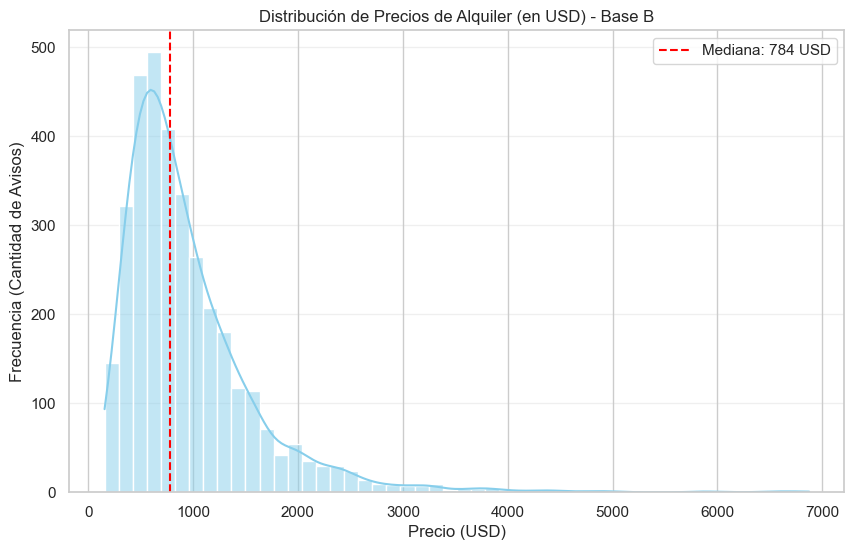

In [ ]:
print("Estadísticas de 'precio_usd' en Base B:")
print(b['precio_usd'].describe().round(2))


plt.figure(figsize=(10, 6))
sns.histplot(b['precio_usd'].dropna(), kde=True, bins=50, color='skyblue')

plt.title('Distribución de Precios de Alquiler (en USD) - Base B')
plt.xlabel('Precio (USD)')
plt.ylabel('Frecuencia (Cantidad de Avisos)')
plt.grid(axis='y', alpha=0.3)


plt.axvline(b['precio_usd'].median(), color='red', linestyle='--', label=f'Mediana: {b["precio_usd"].median():.0f} USD')
plt.legend()

plt.show()

La variable precio_usd presenta una distribución log-normal, con una fuerte concentración en el segmento medio (USD 400-800) y una cola larga representativa del segmento más alto.

Finalmente creamos la PK para poder unificar las tres bases y evitar registros duplicados entre las tres bases. Para eso construiremos la PK con el mismo criterio que para la base a las variables latitud, longitud, superficie y cantidad de ambientes, que llamaremos "PK".

In [ ]:

def crear_pk_b(df, col_superficie):
  
    lat = df['latitud'].astype(str).str.strip().str.replace(' ', '')
    lon = df['longitud'].astype(str).str.strip().str.replace(' ', '')
    sup = df[col_superficie].astype(str).str.strip().str.replace(' ', '')
    
  
    return lat + "|" + lon + "|" + sup

b['PK'] = crear_pk_b(b, 'superficie_cubierta')

# --- CHEQUEO DE RESULTADOS ---
print(f" Reporte de PK en Base B:")
print(f"- Total de registros: {len(b)}")
print(f"- PKs únicas: {b['PK'].nunique()}")
print(f"- Registros duplicados en B (según PK): {b.duplicated(subset=['PK']).sum()}")

display(b[['listing_id', 'latitud', 'longitud', 'superficie_cubierta', 'PK']].head())

 Reporte de PK en Base B:
- Total de registros: 3639
- PKs únicas: 2796
- Registros duplicados en B (según PK): 842


,listing_id,latitud,longitud,superficie_cubierta,PK
0,MLA757902287,-34.549232,-58.425510,50.0,-34.549232|-58.42551|50.0
1,MLA371511639,-34.586467,-58.439921,50.0,-34.586467|-58.439921|50.0
2,MLA154908801,-34.607493,-58.417589,42.0,-34.607493|-58.417589|42.0
3,MLA403100436,-34.567514,-58.487023,66.0,-34.567514|-58.487023|66.0
4,MLA346000441,-34.589963,-58.444575,86.0,-34.589963|-58.444575|86.0


## Base de datos C

In [113]:
c.head()

,codigo,operacion,tipo_inmueble,barrio,precio_publicado,superficie,descripcion,coordenadas,publicado
0,AP-64391,Alquiler,ph,Villa Urquiza,$678.000/mes,55,2 ambientes. 1 dorm. 1 baños. pileta,"-34.57599599633878,-58.47863988110282",10-03-2024
1,AP-82260,Alquiler,ph,Colegiales,$700.000/mes,50,2 ambientes. 1 dorm. 1 baños. balcón. 11 años,"-34.582690398643514,-58.4524965859866",30-11-2024
2,AP-66765,Alquiler,departamento,Caballito,$719.000/mes,41,3 ambientes. 2 baños. 11 años,NaN,28-07-2024
3,AP-42570,Alquiler,departamento,Villa Crespo,$1.391.000/mes,58,3 ambientes. 2 dorm. con cochera. 4 años,NaN,31-12-2024
4,AP-64652,Alquiler,departamento,Recoleta,Consultar,53,3 ambientes. 2 dorm. 2 baños. con cochera. 18 ...,NaN,08-01-2025


In [114]:
c.info()

<class 'pandas.DataFrame'>
RangeIndex: 3699 entries, 0 to 3698
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   codigo            3699 non-null   str  
 1   operacion         3699 non-null   str  
 2   tipo_inmueble     3699 non-null   str  
 3   barrio            3699 non-null   str  
 4   precio_publicado  3699 non-null   str  
 5   superficie        3513 non-null   str  
 6   descripcion       3682 non-null   str  
 7   coordenadas       2235 non-null   str  
 8   publicado         3699 non-null   str  
dtypes: str(9)
memory usage: 676.2 KB


## Unificación de Bases de datos

Con la PK creada en las bases de datos A y B, se unificaran ambas bases teniendo como criterio de filtro aquellos registros "repetidos" entre la Base A y la B. 

In [116]:
# 1. Se identifican los registros de la Base B que NO están en la Base A

b_nuevos = b[~b['PK'].isin(a_final['PK'])].copy()

print(f" Análisis de integración:")
print(f"- Registros originales en A: {len(a_final)}")
print(f"- Registros totales en B: {len(b)}")
print(f"- Registros de B que ya existían en A (descartados): {b['PK'].isin(a_final['PK']).sum()}")
print(f"- Registros nuevos de B a sumar: {len(b_nuevos)}")

# Se seleccionan solo las columnas que ambas bases tienen en común para evitar conflictos
columnas_comunes = list(set(a_final.columns) & set(b_nuevos.columns))
print(f"\n🔗 Unificando por las {len(columnas_comunes)} columnas comunes...")

# Se concatenan los registros de la base A con los registros nuevos de B
df_unificado = pd.concat([a_final[columnas_comunes], b_nuevos[columnas_comunes]], ignore_index=True)


print(f"\n Base de datos unificada.")
print(f"Total de registros finales para el modelo: {len(df_unificado)}")

 Análisis de integración:
- Registros originales en A: 3216
- Registros totales en B: 3639
- Registros de B que ya existían en A (descartados): 0
- Registros nuevos de B a sumar: 3639

🔗 Unificando por las 18 columnas comunes...

 Base de datos unificada.
Total de registros finales para el modelo: 6855


In [117]:
df_unificado.info()

<class 'pandas.DataFrame'>
RangeIndex: 6855 entries, 0 to 6854
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   antiguedad           5509 non-null   float64       
 1   cochera              6855 non-null   int64         
 2   fecha_publicacion    6855 non-null   str           
 3   tipo                 6855 non-null   str           
 4   longitud             6855 non-null   object        
 5   pileta               6855 non-null   int64         
 6   latitud              6855 non-null   object        
 7   dormitorios          6423 non-null   float64       
 8   ambientes_num        6717 non-null   float64       
 9   superficie_cubierta  6668 non-null   float64       
 10  PK                   6668 non-null   str           
 11  zona_barrio          6855 non-null   str           
 12  precio_usd           6642 non-null   float64       
 13  fecha_dt             6855 non-null   datetim